# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [172]:
mnase_analysis = MNaseOriginAnalysis()

In [312]:
replicate = 2
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [497]:
mnase_analysis.compute_sliding_window_counts_all_times(10000, 2000)

In [498]:
# Next, estimate when S starts and ends, probably 30-40 minutes
# Take the heatmap of these timepoints and estimate when replication occurred along the 
# chromosome to estimate the early/late activation origin proximity.

from src.create_models import read_cloccs_posteriors
params = read_cloccs_posteriors('data/2019_cloccs_fits/yl_2019_replicate2/posteriors.txt')

mu0, lambda_len, gamma1, gamma2 = params['mu0'], params['lambda'], params['gamma1'], \
    params['gamma2']

alpha = 28

# Estimate the first S from mu0, lambda, gamma1, and gamma2
g1_len = (lambda_len*gamma1)
s_end = (lambda_len*gamma2)
s_length = s_end - g1_len

# For the first cell cycle, mu0 includes the first G1
# so S starts when Recovery (mu0) ends
first_s_start = -mu0
first_s_end = -mu0+s_length

# The end of the first cycle is computed
# by taking the cell cycle length, subtracting the length of S (to get G1 and G2/M)
# Then subtract out what the first G1 would be.
# Then offset by mu0 length to get the actual timepoint for the end of the first cell cycle
end_of_first_lambd = lambda_len-s_length-g1_len - mu0

print("For cohort {0, 0}:")
print(f"  S is defined from {first_s_start:.2f} - {first_s_end:.2f}")
print(f"  End of the G2/M is: {end_of_first_lambd:.2f}")

For cohort {0, 0}:
  S is defined from 20.15 - 37.13
  End of the G2/M is: 63.28


In [501]:
mnase_analysis.all_window_counts.shape, mnase_analysis.start_indices.shape

((15, 368), (368,))

0

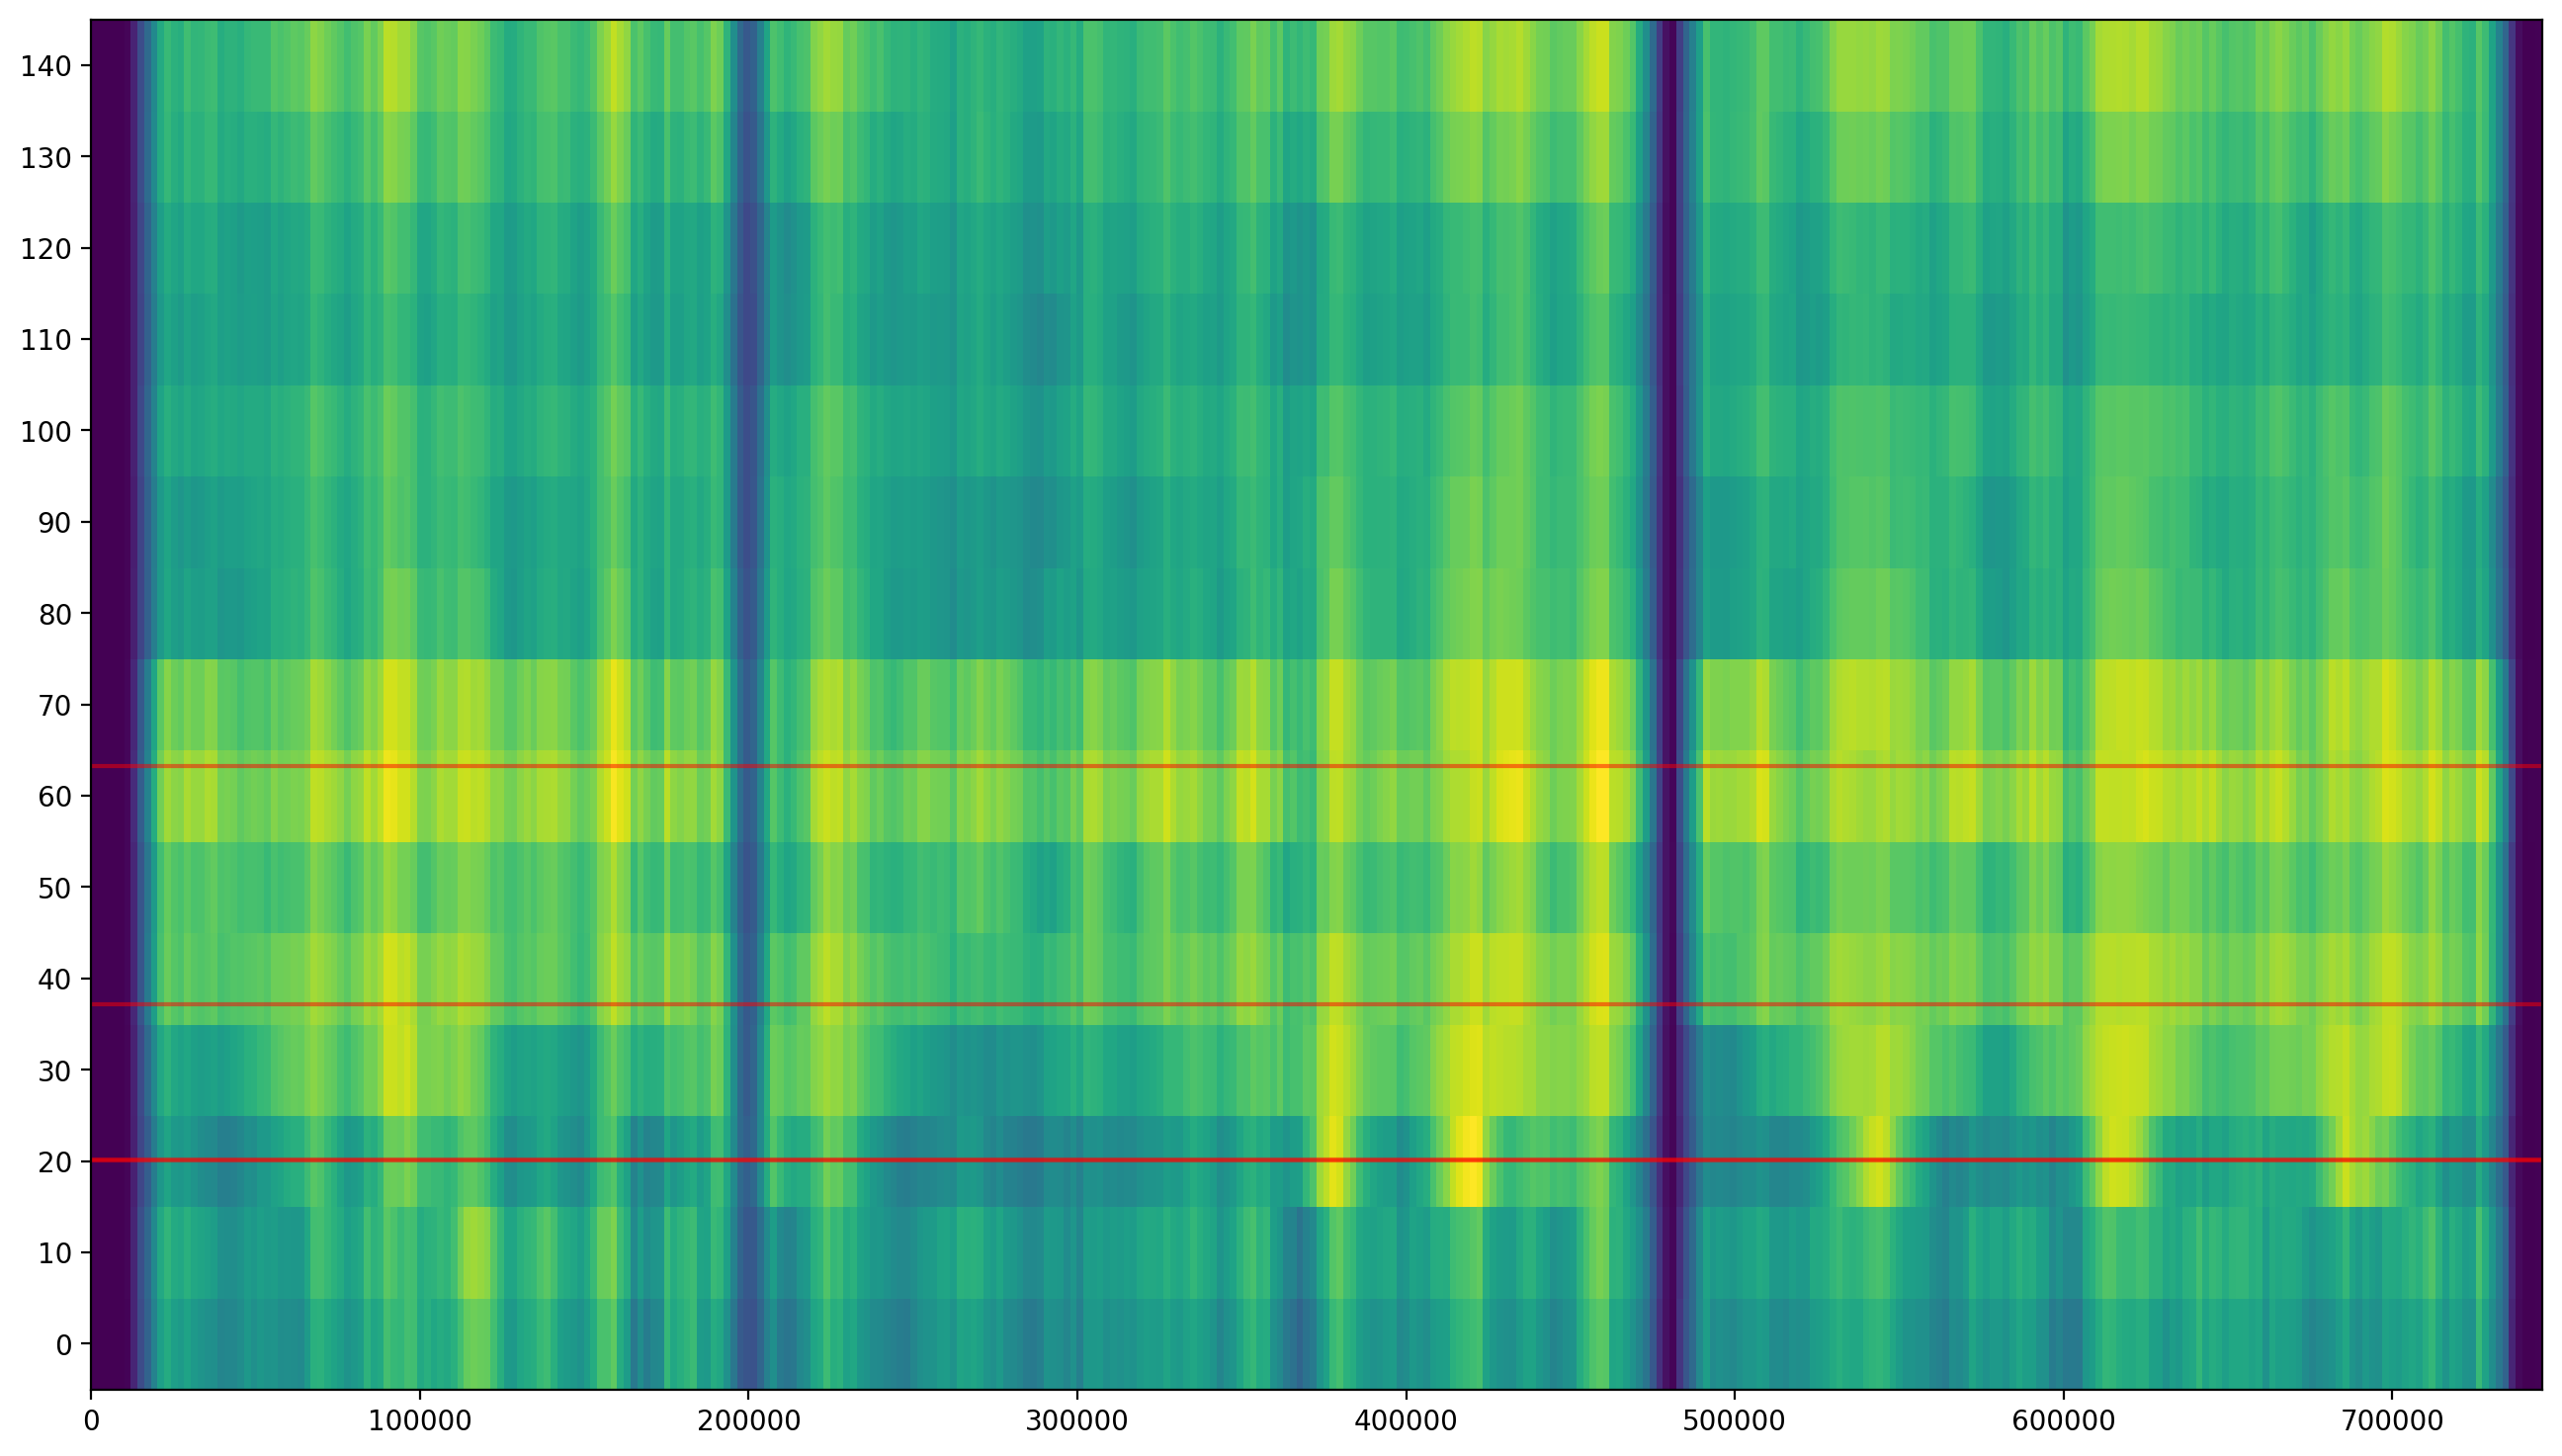

In [510]:
sum_per_time = mnase_analysis.all_window_counts.sum(axis=1)
#sample_normalized = mnase_analysis.all_window_counts / \
#    sum_per_time.reshape((sum_per_time.shape[0], 1))


# Normalize by the expected DNA content at each timepoint

# Through recovery - 1n
# End of S - 2n
# Linearly interpolate the total number of reads for start of S to end of S

sample_normalized = mnase_analysis.all_window_counts

timepoints = mnase_analysis.timepoints

plt.figure(figsize=(16, 9))
plt.imshow(sample_normalized, aspect='auto', origin='lower',
          extent=[0, mnase_analysis.chrom_len, -5, timepoints[-1]+5])

plt.yticks(timepoints)

plt.axhline(first_s_start-g1_len, c='red', alpha=0.5)
plt.axhline(first_s_start, c='red', alpha=0.5)
plt.axhline(first_s_end, c='red', alpha=0.5)
plt.axhline(end_of_first_lambd, c='red', alpha=0.5)

0

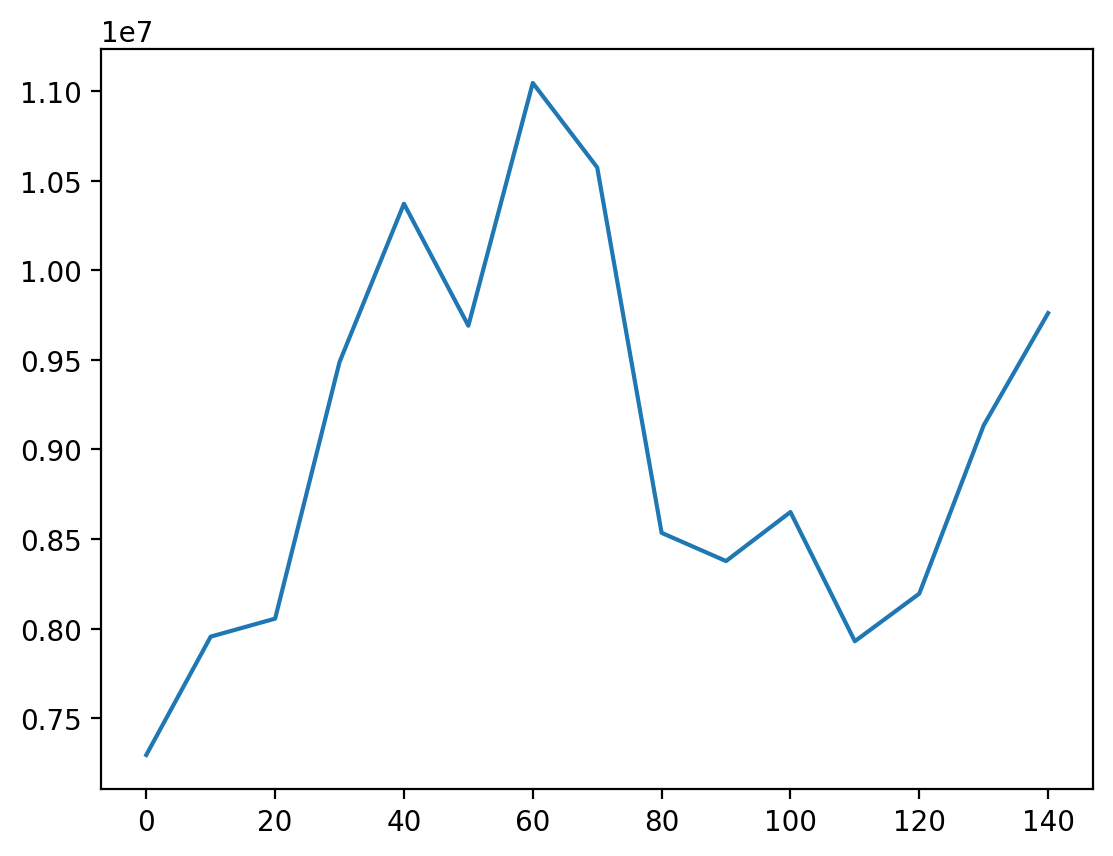

In [511]:
plt.plot(mnase_analysis.timepoints, sample_normalized.sum(axis=1))

In [505]:
sample_normalized.shape

(15, 368)

In [506]:
len(mnase_analysis.start_indices)

368

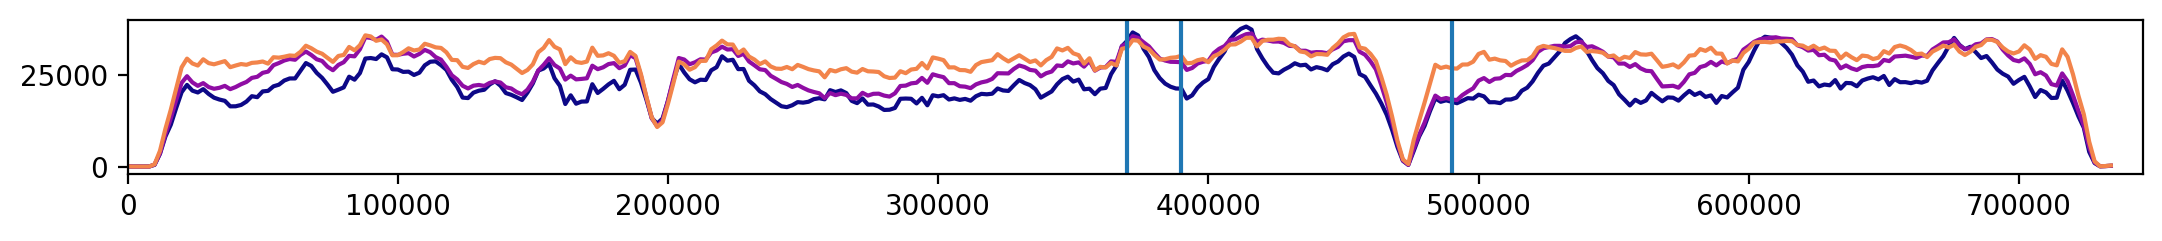

In [507]:
plt.figure(figsize=(13, 1))

cmap = plt.get_cmap('plasma_r')

plt.plot(mnase_analysis.start_indices, sample_normalized[2], color=cmap(1.))
plt.plot(mnase_analysis.start_indices, sample_normalized[3], color=cmap(0.7))
plt.plot(mnase_analysis.start_indices, sample_normalized[4], color=cmap(0.3))
plt.xlim(0, mnase_analysis.chrom_len)

plt.axvline(185*mnase_analysis.step)
plt.axvline(195*mnase_analysis.step)
plt.axvline(245*mnase_analysis.step)


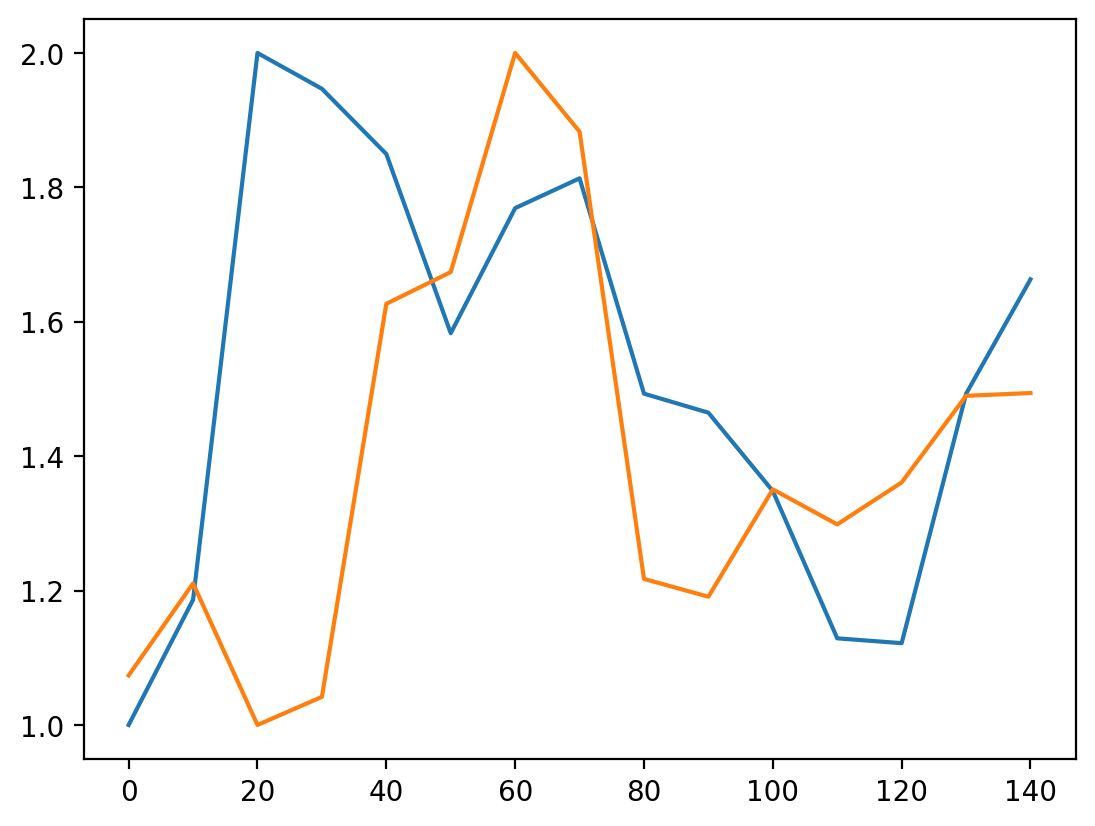

In [509]:

def normalize_bin_by_dna_content(dna_content):
    max_2n = dna_content.max()
    max_1n = dna_content.min()

    # Assumes that dna content cycles from 1 (min) to 2 (max)
    dna_content_normalized = (dna_content-max_1n)/(max_2n-max_1n) + 1.
    return dna_content_normalized


normalize_by_0 = sample_normalized / sample_normalized[0]

dna_content_normalized = normalize_bin_by_dna_content(normalize_by_0[:, 185])
plt.plot(mnase_analysis.timepoints, dna_content_normalized)

dna_content_normalized = normalize_bin_by_dna_content(normalize_by_0[:, 245])
plt.plot(mnase_analysis.timepoints, dna_content_normalized)

# In this example, from 0-30, these point of the genome has not replicated.
# The spike from 1.6 to 1.0 appears to be an artifact of normalization.
# In which, these values are expected to be at 1.0, but at 30 minutes other areas of the
# genome begin replicating, so this point of the genome must drop down in response.

# The fix would be to somehow normalize the number of reads such that areas of the genome
# that are unreplicated like here, should remain 0 until it is replicated (at timepoint 60)
# it appears.

# So unnormalized, the data looks betteer
# from 0-30 the second position hovers around 1.0
# And the first position moves from 1-2 (is replicated early)

# However some kind of normalization will need to be performed

# We can assume that at 60 minutes all DNA has been replicated and the population is
# strictly in G2

# From 0-10 all cells should be in G1 and no replication has happened.
